# Fig: phi (dict elements)

project = ```iP-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>


In [17]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [18]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Results & Figs dir

In [19]:
pal_models = get_palette_models()

chkpts_dir = add_home('Dropbox/chkpts/_IterativeVAE')
figs_dir = pjoin(fig_base_dir, 'figs_2025-03', 'phi')
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(chkpts_dir)), len(os.listdir(figs_dir))

(355, 0)

In [20]:
files = [f for f in os.listdir(chkpts_dir) if 'vH16' in f]
files = sorted(files, key=alphanum_sort_key)

len(files)

100

## Selected fits

In [21]:
seq_len, beta = 16, 24
selected_fits = [
    f for f in files if (
        f't-{seq_len}_b-{beta:0.3g}' in f
        and 'softplus' not in f)
]
print(selected_fits)

[
    'gaussian+relu-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,04:45)',
    'gaussian-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,04:09)',
    'poisson-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,07:38)'
]

## Phi plots

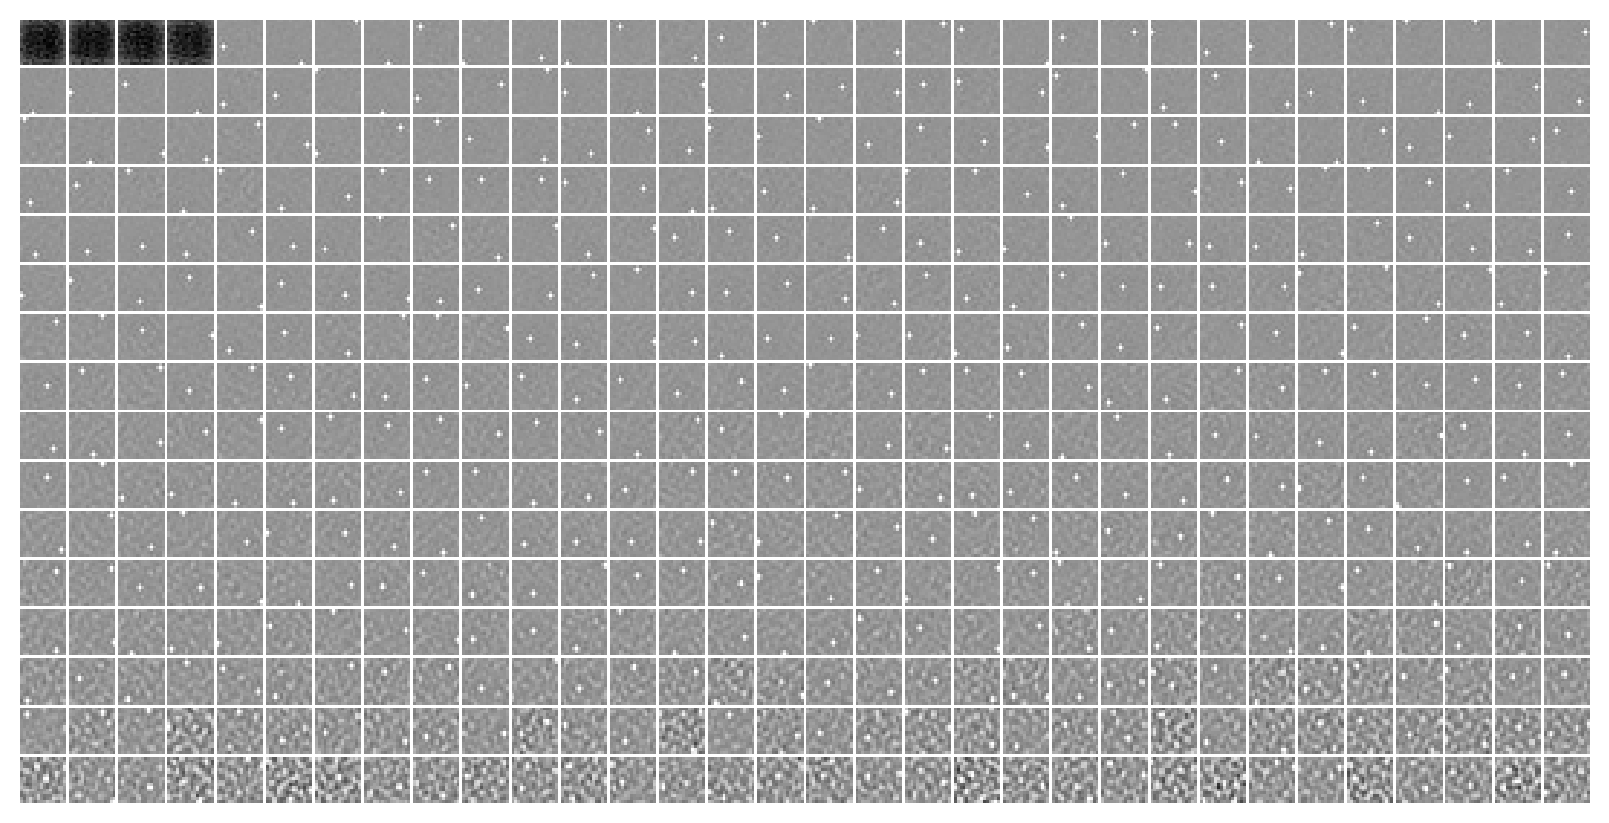

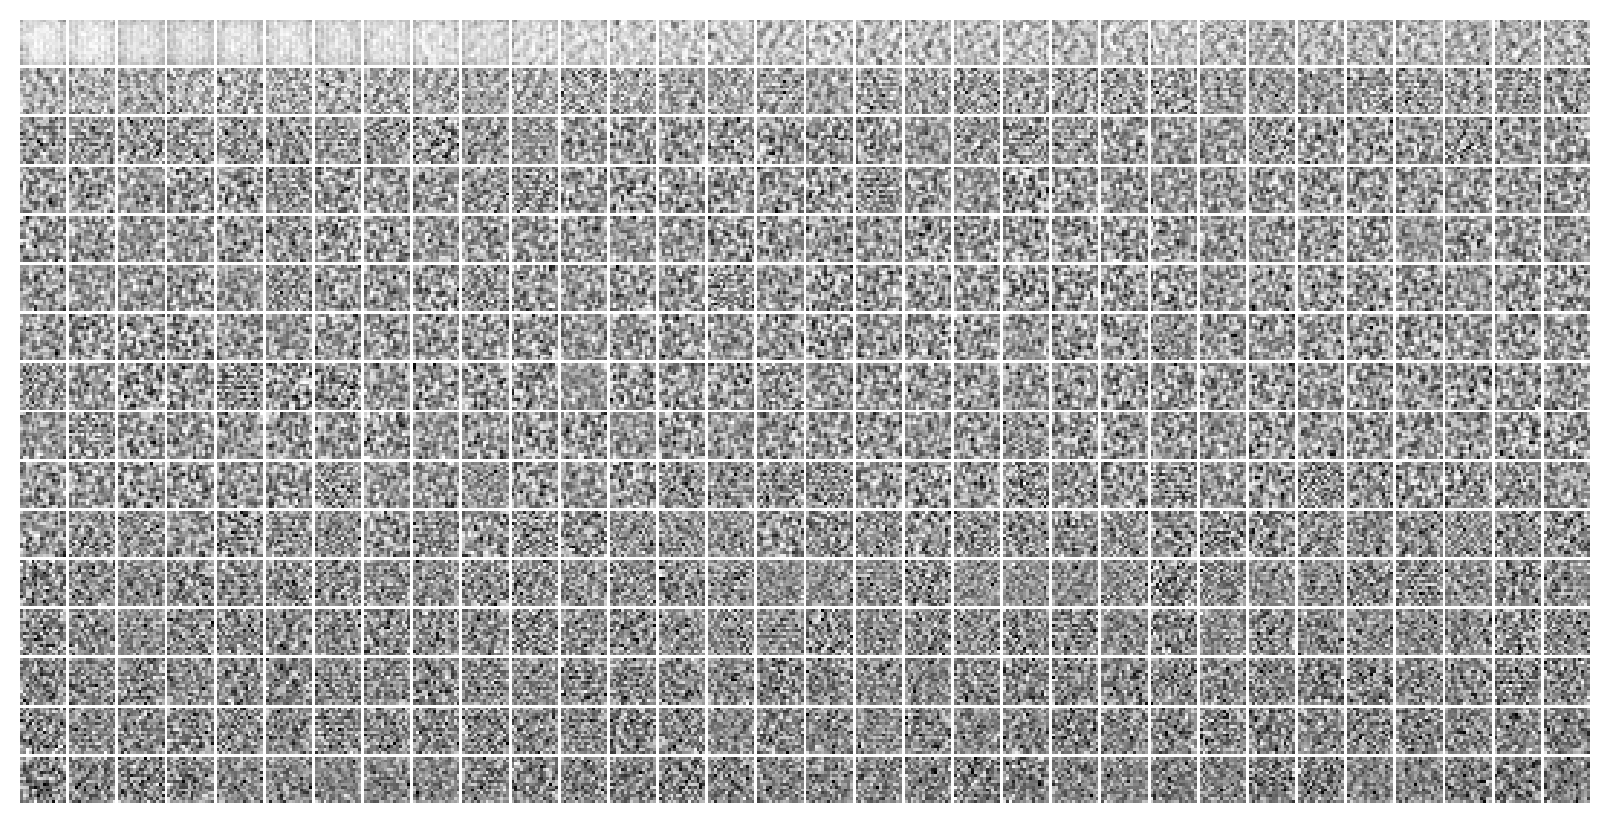

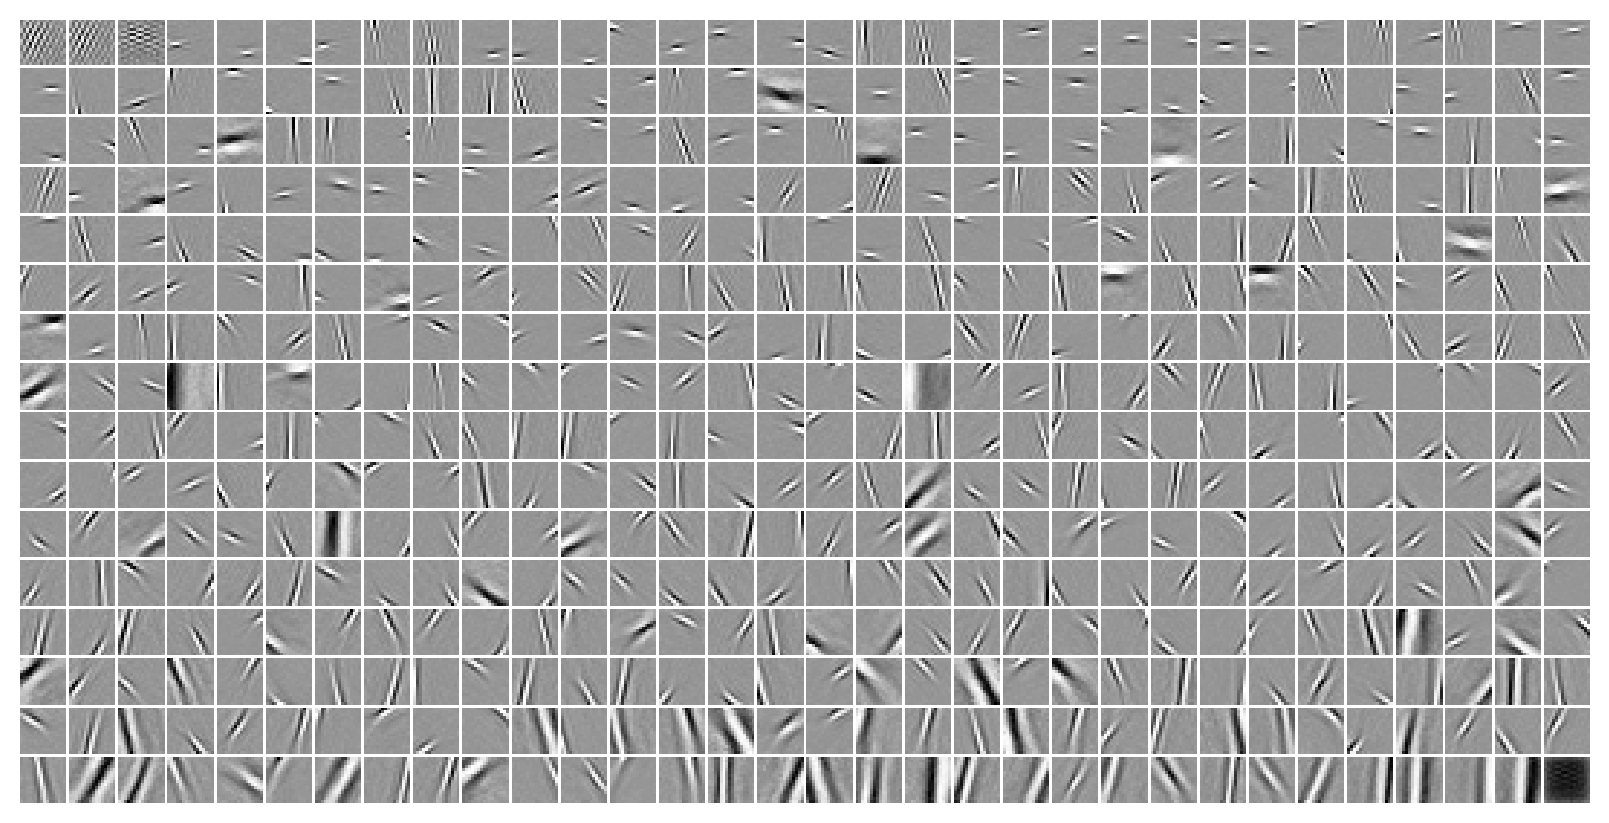

In [22]:
for f in selected_fits:
    tr = load_model_lite(pjoin(chkpts_dir, f))[0]
    u0 = tonp(tr.model.layer.u_init[0].squeeze())
    order = np.argsort(u0)
    fig, _ = tr.model.show(order=order, method='abs-max')
    # save
    model_str = f.split('_')[0].split('-')[0]
    fname = f"phi_{model_str}.png"
    save_fig(fname, figs_dir, fig)

### 5 randomly selected projective fields

In [23]:
ids_dict = {
    'poisson': [380, 47, 281, 117, 338, 161, 24],
    'gaussian': range(70, 77),
    'gaussian+relu': [21, 36, 261, 47, 57, 155, 130], 
}

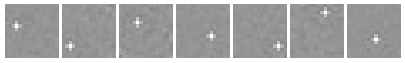

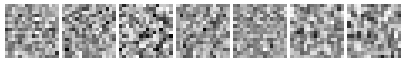

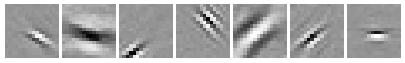

In [24]:
for f in selected_fits:
    # load
    tr = load_model_lite(pjoin(chkpts_dir, f))[0]
    u0 = tonp(tr.model.layer.u_init[0].squeeze())
    order = np.argsort(u0)
    # get ids
    model_str = f.split('_')[0].split('-')[0]
    ids = list(ids_dict[model_str])
    # make fig
    fig, _ = tr.model.show(order=order[ids], method='abs-max', nrows=1, dpi=50)
    # save
    fname = f"phi_{model_str}_{str(ids).replace(' ', '')}.png"
    save_fig(fname, figs_dir, fig)

In [25]:
ids_dict = {
    'poisson': [380, 47, 281, 117, 338],
    'gaussian': range(70, 75),
    'gaussian+relu': [36, 261, 47, 155, 130], 
}

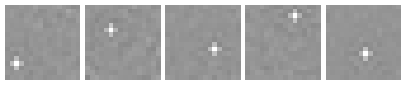

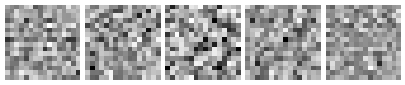

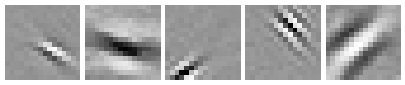

In [26]:
for f in selected_fits:
    # load
    tr = load_model_lite(pjoin(chkpts_dir, f))[0]
    u0 = tonp(tr.model.layer.u_init[0].squeeze())
    order = np.argsort(u0)
    # get ids
    model_str = f.split('_')[0].split('-')[0]
    ids = list(ids_dict[model_str])
    # make fig
    fig, _ = tr.model.show(order=order[ids], method='abs-max', nrows=1, dpi=50)
    # save
    fname = f"phi_{model_str}_{str(ids).replace(' ', '')}.png"
    save_fig(fname, figs_dir, fig)